> **Note (2026-09-10, audit).** This notebook is a **pre-dataset prototype** on synthetic OOK signals. It sits in the Day 08 folder but belongs with the Day 05/06 planning work: its header says the decoder is built "before the faculty dataset arrives", and `DAY_08.MD` does not mention it. Three things to know before reading it:
> 1. **Method names differ from the plan.** Here M1 = fixed threshold, M2 = adaptive threshold, M3 = ML classifier. Days 05/06 and everything after use M0 = fixed, M1 = adaptive, M2 = ML.
> 2. The Day-04 check codes it cites (B2, D1, D5, F6, F7) refer to an earlier draft of `DAY_04.MD` and are not defined in the repository.
> 3. The real-video hook in §9 picks the ROI from the **first frame** and reads `fps` after `cap.release()`; both are wrong for this dataset (4LEDs is dark for its first 1,816 frames — `../../week01/day07/DAY_07.MD` §3). It was superseded by `../day09/roi_extract.py` and `../day11/occ_pipeline.py`.
>
> The synthetic results below (M2 adaptive beats M1 fixed under drift) are correct for the synthetic signal and are the case the real data did **not** present: the supplied videos have no drift, and on them the two thresholds agree on 97–99 % of bits (`../../week03/day15/DAY_15.MD` §2).


# OCC Prototype — synthetic-first decode pipeline

Implements stages **5–9** of the Day-05 workflow (preprocess → synchronize → decide → message → evaluate)
against a **synthetic OOK signal with known ground truth**, so the decoder can be built and checked
*before the faculty dataset arrives*.

Stages 0–4 (ingest, QA, split, ROI, extraction) need real video and are stubbed in the last section —
they plug into the same functions without changing anything below.

| Day-05 stage | Here |
|---|---|
| — transmitter simulator (stands in for stages 0–4) | §1 |
| 5 · Preprocess — denoise / detrend | §2 |
| 6 · Synchronize — symbol period + phase | §3 |
| 7 · Decide — M1 fixed threshold, M2 adaptive | §4 |
| 8 · Message — bits → text | §4 |
| 9 · Evaluate — BER, exact match, runtime | §5 |
| §6 self-check (the `tests/test_pipeline.py` of Day-05 §6) | §6 |
| E1 vs E2 comparison + E4 timing sensitivity | §7–§8 |

**Ground rule carried from Day 04:** ground truth is used *only* in §5 to score. It never touches
synchronization or thresholding (leakage check F7).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

rng_seed = 0
np.set_printoptions(linewidth=120)
plt.rcParams['figure.dpi'] = 110

## 1. Synthetic transmitter — stands in for stages 0–4

Models what a camera actually records: a light that switches at `symbol_rate` bits/s, sampled by a
camera at `fps` frames/s with an exposure window, plus the three degradations Day 02/04 flagged as the
dominant real-world error sources — **ambient/auto-exposure drift**, **sensor noise**, and **low contrast**.

Note `fps / symbol_rate` is the ratio Day 04 calls the most important number in the project: it is the
samples-per-symbol, and must stay above 2 (Nyquist) for per-frame decoding to be possible at all.

In [2]:
def text_to_bits(s):
    return np.array([int(b) for c in s for b in format(ord(c), '08b')], dtype=int)

def bits_to_text(bits):
    n = len(bits) // 8
    return ''.join(chr(int(''.join(map(str, bits[i*8:(i+1)*8])), 2)) for i in range(n))

def synth_signal(bits, fps=30.0, symbol_rate=10.0, phase=0.35, drift=0.0, noise=0.0,
                 lo=0.25, hi=0.85, exposure=0.8, sub=32, seed=0):
    '''Per-frame ROI intensity a camera would record from an OOK transmitter.

    phase    : symbol-clock offset, in symbols (the receiver does not know it)
    drift    : amplitude of slow ambient / auto-exposure wander
    noise    : per-frame gaussian sensor noise
    lo, hi   : 'off' and 'on' intensity -> (hi - lo) is the contrast
    exposure : fraction of the frame interval the shutter is open
    '''
    rng = np.random.default_rng(seed)
    n_frames = int(np.floor(len(bits) * fps / symbol_rate)) - 1
    k = np.arange(n_frames)
    frac = (np.arange(sub) + 0.5) / sub * exposure
    t = (k[:, None] + frac[None, :]) / fps
    idx = np.clip(np.floor(t * symbol_rate - phase).astype(int), 0, len(bits) - 1)
    x = np.where(bits[idx] == 1, hi, lo).mean(axis=1)          # exposure integration
    x = x + drift * np.sin(np.linspace(0, 2.5, n_frames))       # ambient drift
    x = x + rng.normal(0, noise, n_frames)                      # sensor noise
    return np.clip(x, 0.0, 1.0)

MSG = "OCC OK"
BITS = text_to_bits(MSG)
FPS, SYMBOL_RATE = 30.0, 10.0
print(f"message {MSG!r} -> {len(BITS)} bits")
print(f"samples per symbol = {FPS/SYMBOL_RATE:.2f}  (must be > 2)")

message 'OCC OK' -> 48 bits
samples per symbol = 3.00  (must be > 2)


## 2. Stage 5 — Preprocess

Two knobs, both swept later in the sensitivity study:

- **detrend**: subtract a moving average to kill the slow DC wander. Window must be *longer* than a
  symbol period or it eats the signal itself.
- **smooth**: short moving average against noise. Window must be *shorter* than a symbol period or it
  smears symbol edges.

Statistics are fitted per video from that video's own signal — leakage-free by construction (Day 04, F6).

In [3]:
def preprocess(x, smooth=1, detrend=0):
    y = np.asarray(x, float)
    if detrend:
        y = y - uniform_filter1d(y, detrend, mode='nearest')
    if smooth > 1:
        y = uniform_filter1d(y, smooth, mode='nearest')
    return y

## 3. Stage 6 — Synchronization

The receiver knows neither the symbol period (in frames) nor the phase. It recovers both **from the
signal alone** by grid search, scoring each candidate with an F-ratio:

$$\text{score}(T,\phi) = \frac{\operatorname{Var}(\text{per-symbol means})}{\text{mean within-symbol variance}}$$

The correct `(period, phase)` makes symbol windows internally consistent and mutually different, so it
maximises this ratio. Wrong timing splits windows across symbol boundaries, raising within-symbol
variance and lowering the score.

This grid *is* the object measured by the synchronization-robustness metric in Day 05 §3.3.

In [4]:
def _symbol_means(y, period, phase):
    edges = np.arange(phase, len(y) - 1e-9, period)
    idx = np.clip(np.searchsorted(edges, np.arange(len(y)), 'right') - 1, 0, None)
    cnt = np.bincount(idx, minlength=idx.max() + 1)
    tot = np.bincount(idx, weights=y, minlength=idx.max() + 1)
    keep = cnt > 0
    return tot[keep] / cnt[keep], idx, keep

def sync_score(y, period, phase):
    m, idx, keep = _symbol_means(y, period, phase)
    if len(m) < 4:
        return -np.inf
    lut = np.full(idx.max() + 1, np.nan)
    lut[np.flatnonzero(keep)] = m
    within = np.nanmean((y - lut[idx]) ** 2)
    return float(np.var(m) / (within + 1e-9))

def estimate_sync(y, periods, n_phase=16):
    best = (-np.inf, None, None)
    for T in periods:
        for p in np.linspace(0, T, n_phase, endpoint=False):
            s = sync_score(y, T, p)
            if s > best[0]:
                best = (s, T, p)
    return {'score': best[0], 'period': best[1], 'phase': best[2]}

PERIODS = np.arange(2.0, 6.01, 0.02)   # candidate symbol periods, in frames

## 4. Stages 7–8 — Decision and message

- **M1 (baseline, E1)** — one global threshold for the whole video: midpoint of (min, max), or the mean.
- **M2 (main method, E2)** — rolling-window threshold that tracks the local baseline.

Same function, one argument apart. That is deliberate: it keeps the comparison fair, because everything
except the decision rule is identical (Day 05 §1.2).

In [5]:
def decode(y, period, phase, rule='midpoint', window=0):
    m, _, _ = _symbol_means(y, period, phase)
    if window and window < len(m):
        thr = uniform_filter1d(m, window, mode='nearest')      # M2 adaptive
    elif rule == 'mean':
        thr = m.mean()
    else:
        thr = (m.min() + m.max()) / 2                          # M1 fixed midpoint
    return (m > thr).astype(int)

## 5. Stage 9 — Evaluation

BER follows the alignment protocol fixed in Day 05 §3.2: try **both polarities** and a **bounded offset
search**, report the best *together with which polarity and offset were used*. This is not a free
parameter — polarity and start index are unstated dataset conventions (Day 04 D4/D6) — but it must never
be silently applied, so the choice is returned with the number.

Length mismatches are reported separately as `indel`, not folded into the BER.

In [6]:
def ber(pred, ref, max_offset=2):
    best = (1.0, None, None)
    for pol in (1, 0):
        p = pred if pol else 1 - pred
        for off in range(-max_offset, max_offset + 1):
            q = p[off:] if off >= 0 else np.concatenate([np.zeros(-off, int), p])
            n = min(len(q), len(ref))
            if n < len(ref) // 2:
                continue
            e = float((q[:n] != ref[:n]).mean())
            if e < best[0]:
                best = (e, pol, off)
    return {'ber': best[0], 'polarity': best[1], 'offset': best[2], 'indel': len(pred) - len(ref)}

def majority_ber(ref):
    '''BER of always guessing the more common bit — the floor any method must beat.'''
    return float(min(ref.mean(), 1 - ref.mean()))

def run_pipeline(x, ref_bits, smooth=1, detrend=0, window=0, rule='midpoint', periods=PERIODS):
    t0 = time.perf_counter()
    y = preprocess(x, smooth=smooth, detrend=detrend)
    s = estimate_sync(y, periods)
    bits = decode(y, s['period'], s['phase'], rule=rule, window=window)
    text = bits_to_text(bits)
    dt = time.perf_counter() - t0
    out = ber(bits, ref_bits)
    out.update(period=s['period'], phase=s['phase'], bits=bits, text=text,
               exact=text == bits_to_text(ref_bits), runtime_s=dt,
               runtime_s_per_100f=dt / len(x) * 100, majority_ber=majority_ber(ref_bits))
    return out

## 6. Self-check

The Day-05 §6 reproducibility test, inline. It fails loudly if synchronization, thresholding or bit
packing breaks — and it runs today, with no dataset.

In [7]:
def self_check():
    # 1. clean signal decodes exactly, and sync finds the true period
    x = synth_signal(BITS, FPS, SYMBOL_RATE, phase=0.35)
    r = run_pipeline(x, BITS)
    assert r['ber'] == 0.0, r
    assert r['text'] == MSG, r['text']
    assert abs(r['period'] - FPS / SYMBOL_RATE) < 0.1, r['period']

    # 2. round-trip encoding is lossless
    assert bits_to_text(text_to_bits("Hello, OCC!")) == "Hello, OCC!"

    # 3. metric sanity: an inverted stream is caught by the polarity search
    inv = ber(1 - BITS, BITS)
    assert inv['ber'] == 0.0 and inv['polarity'] == 0, inv

    # 4. M2 survives drift + noise where M1 collapses
    xh = synth_signal(BITS, FPS, SYMBOL_RATE, phase=0.35,
                      drift=0.50, noise=0.06, lo=0.32, hi=0.60, seed=3)
    m2 = run_pipeline(xh, BITS, detrend=31, window=9)
    m1 = run_pipeline(xh, BITS)
    assert m2['ber'] < 0.10, m2['ber']
    assert m1['ber'] > 2 * m2['ber'], (m1['ber'], m2['ber'])
    print(f"self-check passed  |  hard case: M1 BER {m1['ber']:.3f}  M2 BER {m2['ber']:.3f}")

self_check()

self-check passed  |  hard case: M1 BER 0.396  M2 BER 0.062


## 7. E1 vs E2 on the hard signal

The comparison the experiment plan calls for, on one signal with known truth. The baseline is not a
straw man — it is exactly right on the clean signal, and fails only when drift moves the DC level under
a threshold that was fitted globally. That failure is the *reason* E2 exists, shown rather than asserted.

In [8]:
x_easy = synth_signal(BITS, FPS, SYMBOL_RATE, phase=0.35)
x_hard = synth_signal(BITS, FPS, SYMBOL_RATE, phase=0.35,
                      drift=0.50, noise=0.06, lo=0.32, hi=0.60, seed=3)

rows = []
for name, x in [('easy', x_easy), ('hard', x_hard)]:
    for method, kw in [('M1_fixed', dict()), ('M2_adaptive', dict(detrend=31, window=9))]:
        r = run_pipeline(x, BITS, **kw)
        rows.append((name, method, r['ber'], r['majority_ber'], r['exact'],
                     r['period'], r['polarity'], r['offset'], r['runtime_s_per_100f'], r['text']))

print(f"{'signal':6} {'method':12} {'BER':>7} {'maj':>6} {'exact':>6} {'T':>5} "
      f"{'pol':>3} {'off':>3} {'s/100f':>7}  decoded")
for r in rows:
    print(f"{r[0]:6} {r[1]:12} {r[2]:7.3f} {r[3]:6.3f} {str(r[4]):>6} {r[5]:5.2f} "
          f"{r[6]:3} {r[7]:3} {r[8]:7.3f}  {r[9]!r}")

signal method           BER    maj  exact     T pol off  s/100f  decoded
easy   M1_fixed       0.000  0.438   True  2.98   1   0   0.374  'OCC OK'
easy   M2_adaptive    0.000  0.438   True  2.98   1   0   0.343  'OCC OK'
hard   M1_fixed       0.396  0.438  False  3.00   1   0   0.347  '\x0fCÿÿÿû'
hard   M2_adaptive    0.062  0.438  False  3.00   1   0   0.408  'OCC0ÏI'


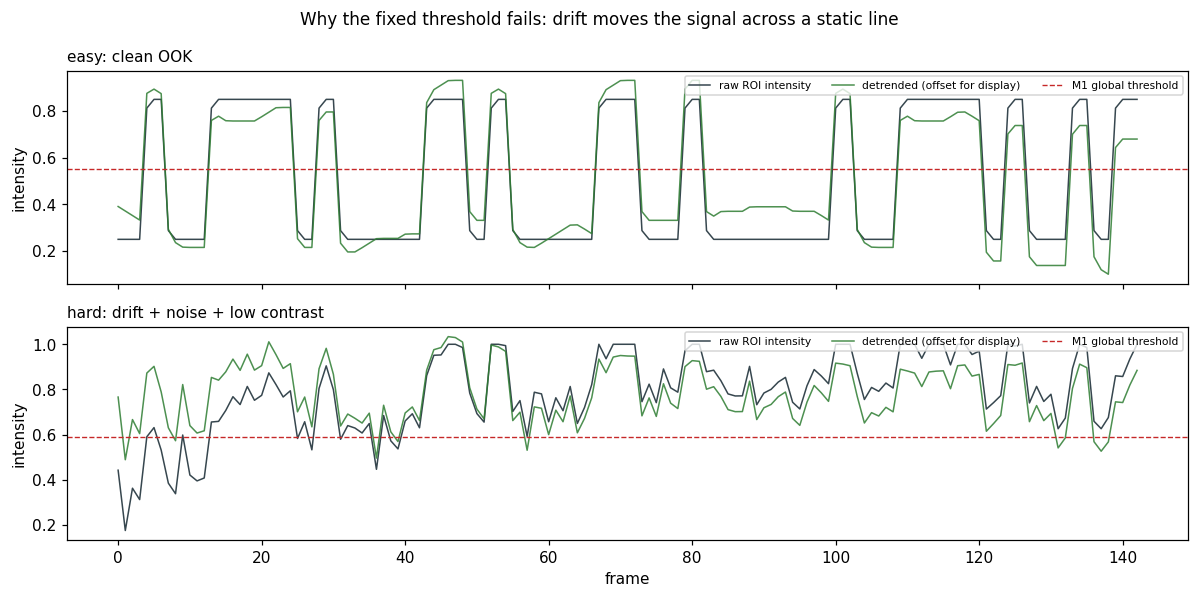

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
for a, (x, title) in zip(ax, [(x_easy, 'easy: clean OOK'),
                              (x_hard, 'hard: drift + noise + low contrast')]):
    a.plot(x, lw=1.0, color='#37474f', label='raw ROI intensity')
    a.plot(preprocess(x, detrend=31) + np.mean(x), lw=1.0, color='#2e7d32',
           alpha=.85, label='detrended (offset for display)')
    a.axhline((x.min() + x.max()) / 2, color='#c62828', ls='--', lw=.9,
              label='M1 global threshold')
    a.set_title(title, fontsize=10, loc='left')
    a.set_ylabel('intensity')
    a.legend(fontsize=7, ncol=3, loc='upper right')
ax[-1].set_xlabel('frame')
fig.suptitle('Why the fixed threshold fails: drift moves the signal across a static line', fontsize=11)
fig.tight_layout()

## 8. E4 preview — timing sensitivity surface

A miniature of the project-specific experiment: BER over the (symbol-period error, phase) grid. This is
the object the Day-05 §3.3 robustness metrics are read off — the tolerance window is the widest
contiguous band under the criterion, and the robust-grid fraction is the share of the grid below it.

robust-grid fraction (BER <= 10%) : 7.26%
period tolerance at best phase           : -2.0% .. +1.0%


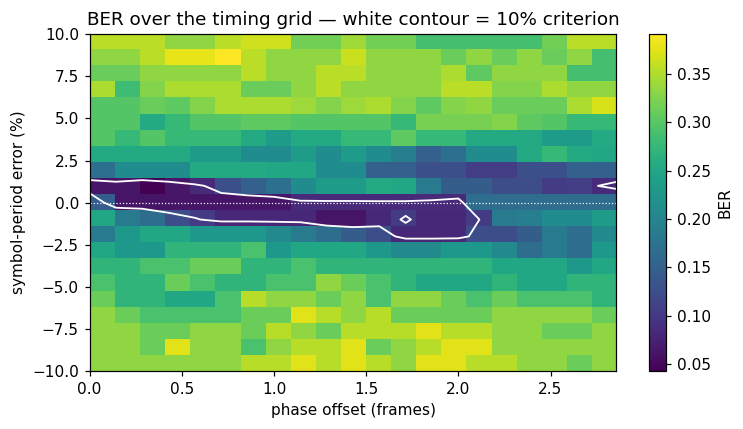

In [10]:
T_true = FPS / SYMBOL_RATE
p_err = np.linspace(-0.10, 0.10, 21)                 # +/-10% period error
phases = np.linspace(0, T_true, 21, endpoint=False)

grid = np.array([[ber(decode(preprocess(x_hard, detrend=31), T_true * (1 + e), ph, window=9),
                      BITS)['ber']
                  for ph in phases] for e in p_err])

CRIT = 0.10
band = p_err[(grid.min(axis=1) <= CRIT)]
print(f"robust-grid fraction (BER <= {CRIT:.0%}) : {(grid <= CRIT).mean():.2%}")
print(f"period tolerance at best phase           : {band.min():+.1%} .. {band.max():+.1%}"
      if len(band) else "period tolerance: none")

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(grid, aspect='auto', origin='lower', cmap='viridis',
               extent=[phases[0], phases[-1], p_err[0] * 100, p_err[-1] * 100])
ax.contour(phases, p_err * 100, grid, levels=[CRIT], colors='w', linewidths=1.2)
ax.axhline(0, color='w', ls=':', lw=.8)
ax.set(xlabel='phase offset (frames)', ylabel='symbol-period error (%)',
       title=f'BER over the timing grid — white contour = {CRIT:.0%} criterion')
fig.colorbar(im, label='BER')
fig.tight_layout()

## 9. Hook for real video — stages 3–4

The only thing the real dataset changes is where `x` comes from. Everything above is untouched.
Fill the ROI logic once Day-04 check B2 says whether the ROI is static or moving.

In [11]:
def extract_signal_from_video(path, roi=None):
    '''Stages 3-4: video -> per-frame ROI intensity table (Day 04 s1.4 columns).

    roi = (x, y, w, h) or None to auto-pick the brightest blob from the first frame.
    Returns the same 1-D array shape the pipeline above already consumes.
    '''
    import cv2
    cap = cv2.VideoCapture(str(path))
    rows = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        g = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if roi is None:                                   # brightest 15x15 window, once
            blur = cv2.GaussianBlur(g, (15, 15), 0)
            _, _, _, (cx, cy) = cv2.minMaxLoc(blur)
            roi = (max(cx - 15, 0), max(cy - 15, 0), 30, 30)
        x0, y0, w, h = roi
        patch = g[y0:y0 + h, x0:x0 + w].astype(float) / 255.0
        rows.append((patch.mean(), patch.max(), patch.std(), (patch >= 1.0).mean()))
    cap.release()
    meta = {'fps': cap.get(cv2.CAP_PROP_FPS) if rows else None, 'roi': roi, 'n_frames': len(rows)}
    return np.array([r[0] for r in rows]), np.array(rows), meta

# usage once the dataset lands:
#   x, table, meta = extract_signal_from_video('data/raw/videos/vid01.mp4')
#   r = run_pipeline(x, ref_bits, detrend=31, window=9,
#                    periods=np.arange(2.0, meta['fps'] / 2, 0.02))
print("stages 3-4 ready; stages 5-9 verified above on synthetic truth")

stages 3-4 ready; stages 5-9 verified above on synthetic truth


### What this notebook does *not* do yet

- Stages 0–2 (ingest, QA, split) — need real files.
- ROI tracking for moving transmitters — blocked on Day-04 check B2.
- M3, the ML classifier — blocked on Day-04 check D1 (label granularity).
- Deframing (preamble / parity / Manchester) — blocked on Day-04 check D5. Currently bits map straight
  to 8-bit ASCII, MSB first, which is an **assumption**, not a confirmed convention.